In [17]:
import numpy as np 
import pandas as pd 
%matplotlib inline 
import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')
from importlib import reload
import figure_utils
reload(figure_utils)
from figure_utils import (
    format_model_str,
    build_model_palette,
    get_standard_hue_order,
    get_standard_base_colors,
    model_label,
)

In [2]:
### Get results from dir

def get_results_from_dict(results_dict):
    row_records = []
    for score_type, score_dict in results_dict.items():
        if "scores" in score_type:
            for parameter, param_dict in score_dict.items():
                for fold_idx, score in enumerate(param_dict['values']):
                    record = {
                        'parameter': parameter,
                        'score_type': score_type,
                        'score': score,
                        'fold': fold_idx,
                    }
                    row_records.append(record)
    return row_records

param_decoding_results_dir = Path("parameter_decoding_v2")
results_pkls = list(param_decoding_results_dir.rglob("*kell*/*_r2_decoding_values*.pkl"))

results_dfs = []
for ix, file_path in enumerate(results_pkls):
    results_dict = pd.read_pickle(file_path)
    results_records = get_results_from_dict(results_dict)

    results_df = pd.DataFrame(results_records)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    
    # Use format_model_str from figure_utils to get normalized model name
    model_name, arch, _, eq_lmbda = format_model_str(file_path)
    results_df['model_name'] = model_name
    results_df['model'] = arch
    results_df['eq_lmbda'] = eq_lmbda if eq_lmbda else ''

    results_dfs.append(results_df)

results = pd.concat(results_dfs, axis=0, ignore_index=True).drop_duplicates()

# Pivot so score_type becomes two columns: r2_scores and pr2_scores
id_cols = ['parameter', 'layer', 'model_name', 'model', 'eq_lmbda', 'fold']
results = results.pivot(index=id_cols, columns='score_type', values='score').reset_index()

In [3]:
results

score_type,parameter,layer,model_name,model,eq_lmbda,fold,pr2_scores,r2_scores
0,% Time warp,relu0,CochDNN9 scaled ssl λ=0.0,kell2018,0.0,0,0.874960,0.874954
1,% Time warp,relu0,CochDNN9 scaled ssl λ=0.0,kell2018,0.0,1,0.886195,0.885236
2,% Time warp,relu0,CochDNN9 scaled ssl λ=0.0,kell2018,0.0,2,0.882971,0.882820
3,% Time warp,relu0,CochDNN9 scaled ssl λ=0.0,kell2018,0.0,3,0.887305,0.887203
4,% Time warp,relu0,CochDNN9 scaled ssl λ=0.0,kell2018,0.0,4,0.884607,0.884585
...,...,...,...,...,...,...,...,...
2480,dB SNR,relufc,CochDNN9 supervised word,kell2018,,0,0.152695,-1.764627
2481,dB SNR,relufc,CochDNN9 supervised word,kell2018,,1,0.154401,-1.453614
2482,dB SNR,relufc,CochDNN9 supervised word,kell2018,,2,0.137116,-1.604089
2483,dB SNR,relufc,CochDNN9 supervised word,kell2018,,3,0.192389,-1.350274


In [4]:
# Show normalized model names (used for plotting)
results.model_name.value_counts()

model_name
CochDNN9 scaled ssl λ=0.0         210
CochDNN9 scaled ssl λ=0.5         210
CochDNN9 scaled supervised        210
CochDNN9 ssl λ=0.0                210
CochDNN9 ssl λ=0.1                210
CochDNN9 ssl λ=0.2                210
CochDNN9 ssl λ=0.3                210
CochDNN9 ssl λ=0.4                210
CochDNN9 supervised audioset      210
CochDNN9 supervised multi-task    210
CochDNN9 supervised word          210
CochDNN9 ssl λ=0.5                175
Name: count, dtype: int64

In [5]:
# Use standardized model order and colors from figure_utils
# Filter to models that are actually in the data
all_models_in_data = results['model_name'].unique()
std_order = get_standard_hue_order()
model_plot_order = [m for m in std_order if m in all_models_in_data]
# Add any models in data that aren't in standard order
extra_models = [m for m in all_models_in_data if m not in model_plot_order]
model_plot_order = model_plot_order + extra_models

# Build palette using figure_utils
base_colors = get_standard_base_colors()
palette_dict = build_model_palette(model_plot_order, base_colors)

print("Models in data:", model_plot_order)

Models in data: ['CochDNN9 supervised multi-task', 'CochDNN9 supervised word', 'CochDNN9 supervised audioset', 'CochDNN9 scaled supervised', 'CochDNN9 ssl λ=0.0', 'CochDNN9 ssl λ=0.1', 'CochDNN9 ssl λ=0.2', 'CochDNN9 ssl λ=0.3', 'CochDNN9 ssl λ=0.4', 'CochDNN9 ssl λ=0.5', 'CochDNN9 scaled ssl λ=0.0', 'CochDNN9 scaled ssl λ=0.5']


In [6]:
PARAMETER_ORDER = [
                'dB SNR',
                '% Time warp',
                'Time shift (s)',
                'Pitch (semitones)',
                'Filter high cutoff',
                'Filter low cutoff',
                'Filter order',
]

Text(0.5, 1, 'CochCNN9 parameter decoding at layer relu4')

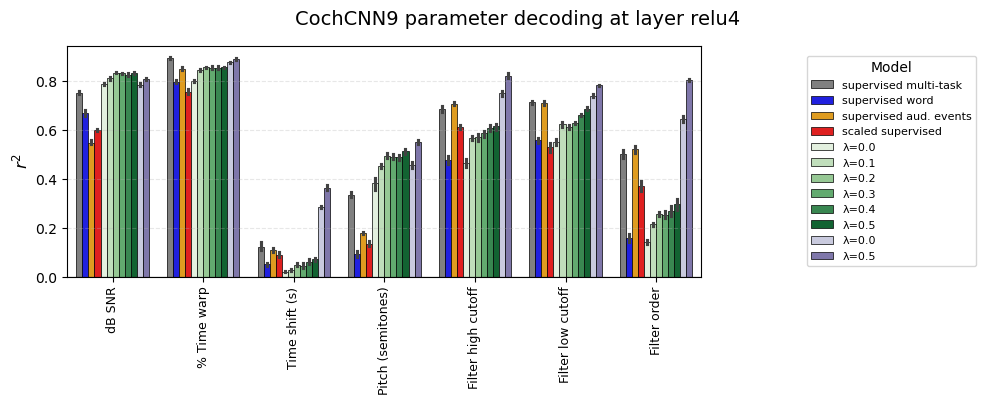

In [7]:
kell_results = results[results.model.str.contains('kell')].reset_index(drop=True)

# Filter model_plot_order to only include models present in kell_results
model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Create visualization with barplot (3) : legend (1) ratio
panel_size = 3
fig, axes = plt.subplots(1, 2, figsize=(panel_size * 4, panel_size), 
                          gridspec_kw={'width_ratios': [3, 1]})
# axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relu4']

for idx, layer in enumerate(layers):
    layer_data = kell_results[kell_results['layer'] == layer]
    # Create grouped bar plot: parameter on x, hue by model
    sns.barplot(
        data=layer_data,
        x='parameter',
        y='pr2_scores',
        hue='model_name',
        hue_order=model_order,
        order=PARAMETER_ORDER,
        ax=axes[idx],
        palette=[palette_dict[m] for m in model_order],
        linewidth=0.5,
        linestyle='-',
        edgecolor='black',
        capsize=0,
    )
    
    # axes[idx].set_title(layer, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    
    # Rotate x-axis labels 90 degrees and center them under tick groups
    axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
    # Get the x-tick positions and labels
    tick_positions = axes[idx].get_xticks()
    tick_labels = axes[idx].get_xticklabels()
    # Set labels with centered alignment
    for label in tick_labels:
        label.set_ha('center')
        label.set_rotation(90)
    
    # Only show ylabel on first subplot (top left)
    if idx == 0:
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    elif idx == 3:  # First panel of second row
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    else:
        axes[idx].set_ylabel('')
    
    # Store legend handles and labels from first plot before removing
    if idx == 0:
        handles, labels = axes[idx].get_legend_handles_labels()
    # Remove legend from all subplots
    axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[-1].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[-1].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle(f'CochCNN9 parameter decoding at layer {layer}', fontsize=14,  y=1)
# Reduce whitespace between panels
# plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)

# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')


Text(0.5, 1, 'CochCNN9 parameter decoding at layer relufc')

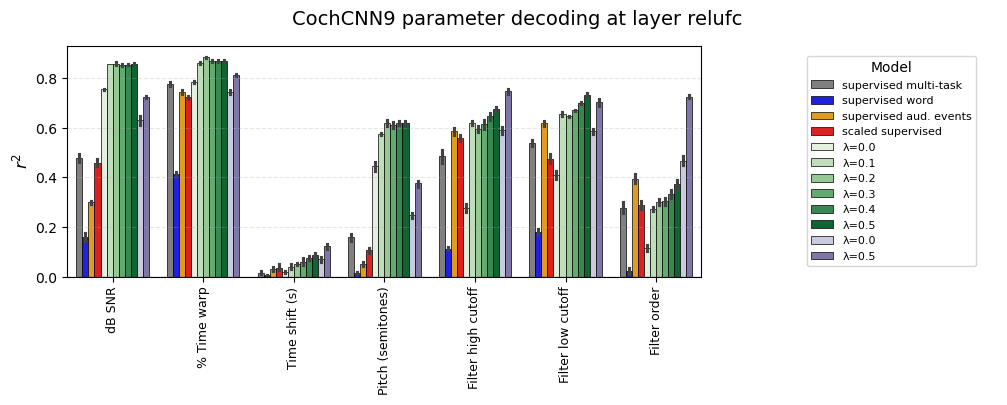

In [8]:
kell_results = results[results.model.str.contains('kell')].reset_index(drop=True)

# Filter model_plot_order to only include models present in kell_results
model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Create visualization with barplot (3) : legend (1) ratio
panel_size = 3
fig, axes = plt.subplots(1, 2, figsize=(panel_size * 4, panel_size), 
                          gridspec_kw={'width_ratios': [3, 1]})
# axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relufc']

for idx, layer in enumerate(layers):
    layer_data = kell_results[kell_results['layer'] == layer]
    # Create grouped bar plot: parameter on x, hue by model
    sns.barplot(
        data=layer_data,
        x='parameter',
        y='pr2_scores',
        hue='model_name',
        hue_order=model_order,
        order=PARAMETER_ORDER,
        ax=axes[idx],
        palette=[palette_dict[m] for m in model_order],
        linewidth=0.5,
        linestyle='-',
        edgecolor='black',
        capsize=0,
    )
    
    # axes[idx].set_title(layer, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    
    # Rotate x-axis labels 90 degrees and center them under tick groups
    axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
    # Get the x-tick positions and labels
    tick_positions = axes[idx].get_xticks()
    tick_labels = axes[idx].get_xticklabels()
    # Set labels with centered alignment
    for label in tick_labels:
        label.set_ha('center')
        label.set_rotation(90)
    
    # Only show ylabel on first subplot (top left)
    if idx == 0:
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    elif idx == 3:  # First panel of second row
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    else:
        axes[idx].set_ylabel('')
    
    # Store legend handles and labels from first plot before removing
    if idx == 0:
        handles, labels = axes[idx].get_legend_handles_labels()
    # Remove legend from all subplots
    axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[-1].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[-1].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle(f'CochCNN9 parameter decoding at layer {layer}', fontsize=14,  y=1)
# Reduce whitespace between panels
# plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)

# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')


Text(0.5, 1, 'CochCNN9 parameter decoding at layer relu4')

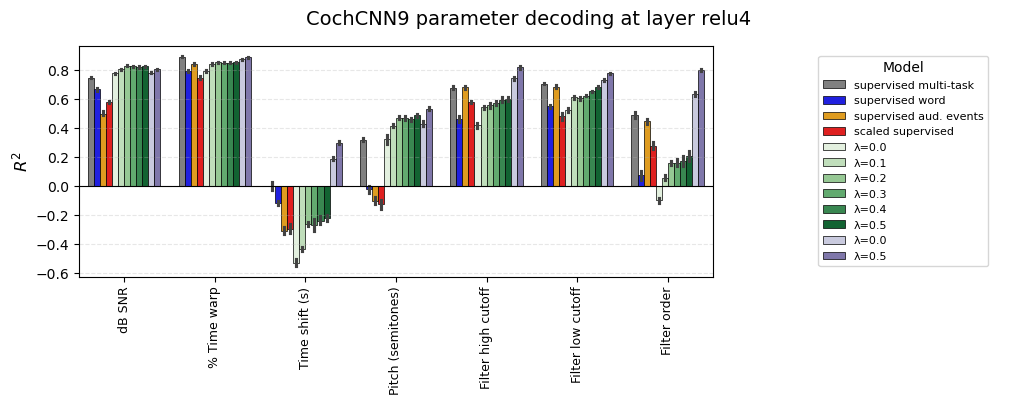

In [8]:
kell_results = results[results.model.str.contains('kell')].reset_index(drop=True)

# Filter model_plot_order to only include models present in kell_results
model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Create visualization with barplot (3) : legend (1) ratio
panel_size = 3
fig, axes = plt.subplots(1, 2, figsize=(panel_size * 4, panel_size), 
                          gridspec_kw={'width_ratios': [3, 1]})
# axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relu4']

for idx, layer in enumerate(layers):
    layer_data = kell_results[kell_results['layer'] == layer]
    # Create grouped bar plot: parameter on x, hue by model
    sns.barplot(
        data=layer_data,
        x='parameter',
        y='r2_scores',
        hue='model_name',
        hue_order=model_order,
        order=PARAMETER_ORDER,
        ax=axes[idx],
        palette=[palette_dict[m] for m in model_order],
        linewidth=0.5,
        linestyle='-',
        edgecolor='black',
        capsize=0,
    )
    
    # axes[idx].set_title(layer, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    
    # Rotate x-axis labels 90 degrees and center them under tick groups
    axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
    # Get the x-tick positions and labels
    tick_positions = axes[idx].get_xticks()
    tick_labels = axes[idx].get_xticklabels()
    # Set labels with centered alignment
    for label in tick_labels:
        label.set_ha('center')
        label.set_rotation(90)
    
    # Only show ylabel on first subplot (top left)
    axes[idx].set_ylabel('$R^2$', fontsize=12)

    
    # Store legend handles and labels from first plot before removing
    if idx == 0:
        handles, labels = axes[idx].get_legend_handles_labels()
    # Remove legend from all subplots
    axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[-1].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[-1].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle(f'CochCNN9 parameter decoding at layer {layer}', fontsize=14,  y=1)
# Reduce whitespace between panels
# plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)

# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')


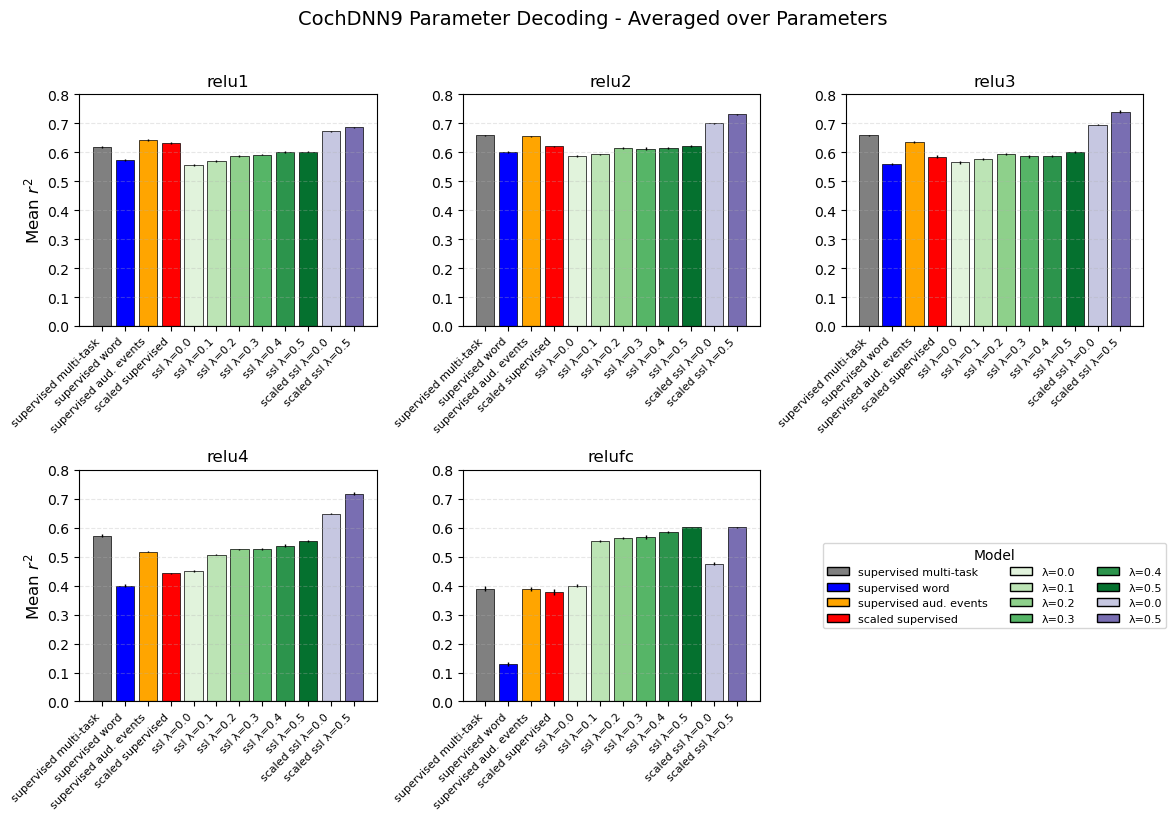

In [18]:
# Average over parameters, plot model on x-axis - one panel per layer
layers = ['relu1', 'relu2', 'relu3', 'relu4', 'relufc']

# Create figure with 2 rows x 3 cols (5 layers + 1 legend panel)
panel_size = 4
fig, axes = plt.subplots(2, 3, figsize=(3 * panel_size, 2 * panel_size))
axes = axes.flatten()

# Get colors for each model
colors = [palette_dict[m] for m in model_order]
x_pos = np.arange(len(model_order))

for idx, layer in enumerate(layers):
    ax = axes[idx]
    layer_data = kell_results[kell_results['layer'] == layer]
    
    # Per run (fold): mean over parameters; then mean and std across runs
    run_means = layer_data.groupby(['model_name', 'fold'])['pr2_scores'].mean().reset_index()
    run_means = run_means.rename(columns={'pr2_scores': 'mean_r2_per_run'})
    avg_data = run_means.groupby('model_name')['mean_r2_per_run'].agg(['mean', 'std']).reset_index()
    avg_data.columns = ['model_name', 'mean_r2', 'std_r2']
    
    # Reorder by model_order (handle missing models gracefully)
    available_models = [m for m in model_order if m in avg_data['model_name'].values]
    avg_data = avg_data.set_index('model_name').loc[available_models].reset_index()
    
    # Create barplot
    ax.bar(x_pos[:len(available_models)], avg_data['mean_r2'].values, 
           color=[palette_dict[m] for m in available_models], 
           edgecolor='black', linewidth=0.5)
    
    # Add error bars
    ax.errorbar(x_pos[:len(available_models)], avg_data['mean_r2'].values, 
                yerr=avg_data['std_r2'].values,
                fmt='none', color='black', capsize=0, capthick=1, elinewidth=1)
    
    # Set labels
    ax.set_title(layer, fontsize=12)
    ax.set_xlabel('')
    ax.set_xticks(x_pos[:len(available_models)])
    ax.set_xticklabels([model_label(m, with_ssl=True) for m in available_models], rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=0, color='black', linewidth=0.8)
    
    # Only show ylabel on leftmost panels
    if idx in [0, 3]:
        ax.set_ylabel('Mean $r^2$', fontsize=12)
    else:
        ax.set_ylabel('')
    ax.set_ylim(0.0, 0.8)

# Create legend in the 6th panel
axes[5].axis('off')
# Create legend handles manually
legend_handles = [Patch(facecolor=palette_dict[m], edgecolor='black', label=model_label(m)) 
                  for m in model_order]
axes[5].legend(handles=legend_handles, title='Model', loc='center', fontsize=8, frameon=True, ncol=3)

plt.suptitle('CochDNN9 Parameter Decoding - Averaged over Parameters', fontsize=14, y=1.02)
plt.tight_layout()

## Plot Kell2018 models

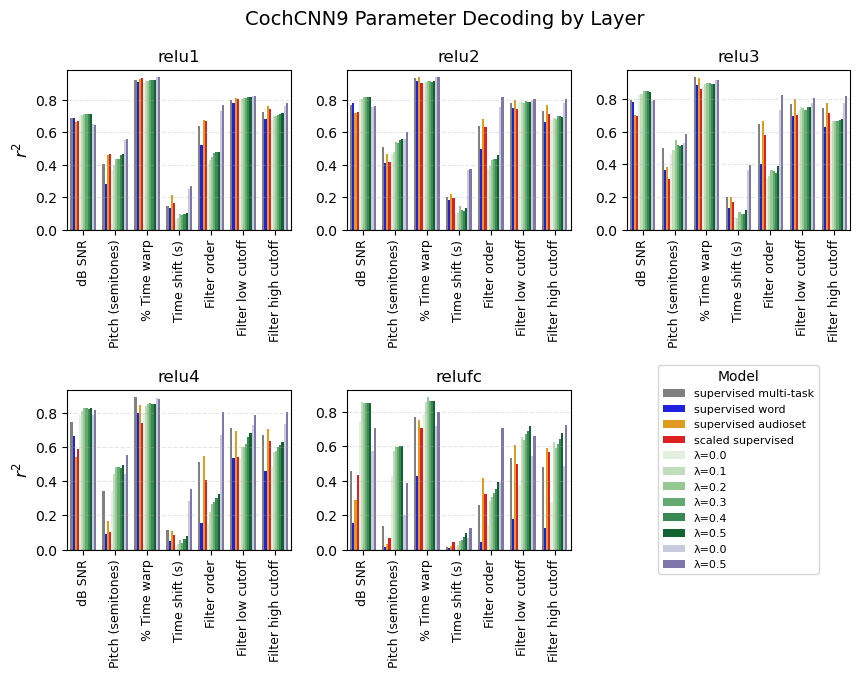

In [8]:
kell_results = results[results.model.str.contains('kell')].reset_index(drop=True)

# Filter model_plot_order to only include models present in kell_results
model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Get parameter order
parameter_order = kell_results['parameter'].unique()

# Create visualization with 2 rows - square panels
# Layout: Row 1: 3 panels, Row 2: 2 panels (with empty space)
panel_size = 3 # Size of each square panel (reduced for better aspect ratio)
fig, axes = plt.subplots(2, 3, figsize=(3 * panel_size, 2 * panel_size), sharey=False)
axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relu1', 'relu2', 'relu3', 'relu4', 'relufc']

for idx, layer in enumerate(layers):
    layer_data = kell_results[kell_results['layer'] == layer]
    
    # Create grouped bar plot: parameter on x, hue by model
    sns.barplot(
        data=layer_data,
        x='parameter',
        y='pr2_scores',
        hue='model_name',
        hue_order=model_order,
        order=parameter_order,
        ax=axes[idx],
        palette=[palette_dict[m] for m in model_order]
    )
    
    axes[idx].set_title(layer, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    
    # Rotate x-axis labels 90 degrees and center them under tick groups
    axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
    # Get the x-tick positions and labels
    tick_positions = axes[idx].get_xticks()
    tick_labels = axes[idx].get_xticklabels()
    # Set labels with centered alignment
    for label in tick_labels:
        label.set_ha('center')
        label.set_rotation(90)
    
    # Only show ylabel on first subplot (top left)
    if idx == 0:
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    elif idx == 3:  # First panel of second row
        axes[idx].set_ylabel('$r^2$', fontsize=12)
    else:
        axes[idx].set_ylabel('')
    
    # Store legend handles and labels from first plot before removing
    if idx == 0:
        handles, labels = axes[idx].get_legend_handles_labels()
    # Remove legend from all subplots
    axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[5].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[5].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle('CochCNN9 Parameter Decoding by Layer', fontsize=14,  y=1)
# Reduce whitespace between panels
plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')


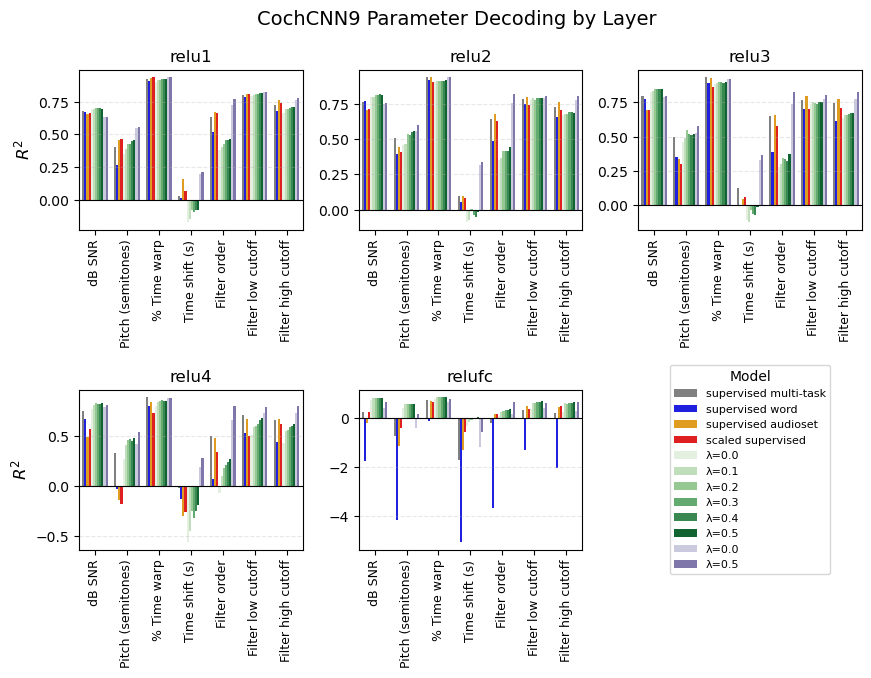

In [9]:
kell_results = results[results.model.str.contains('kell')].reset_index(drop=True)

# Filter model_plot_order to only include models present in kell_results
model_order = [m for m in model_plot_order if m in kell_results['model_name'].unique()]

# Get parameter order
parameter_order = kell_results['parameter'].unique()

# Create visualization with 2 rows - square panels
# Layout: Row 1: 3 panels, Row 2: 2 panels (with empty space)
panel_size = 3 # Size of each square panel (reduced for better aspect ratio)
fig, axes = plt.subplots(2, 3, figsize=(3 * panel_size, 2 * panel_size), sharey=False)
axes = axes.flatten()  # Flatten to 1D array for easier indexing
layers = ['relu1', 'relu2', 'relu3', 'relu4', 'relufc']

for idx, layer in enumerate(layers):
    layer_data = kell_results[kell_results['layer'] == layer]
    
    # Create grouped bar plot: parameter on x, hue by model
    sns.barplot(
        data=layer_data,
        x='parameter',
        y='r2_scores',
        hue='model_name',
        hue_order=model_order,
        order=parameter_order,
        ax=axes[idx],
        palette=[palette_dict[m] for m in model_order]
    )
    
    axes[idx].set_title(layer, fontsize=12)
    axes[idx].set_xlabel('')
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    axes[idx].axhline(y=0, color='black', linewidth=0.8)
    
    # Rotate x-axis labels 90 degrees and center them under tick groups
    axes[idx].tick_params(axis='x', rotation=90, labelsize=9)
    # Get the x-tick positions and labels
    tick_positions = axes[idx].get_xticks()
    tick_labels = axes[idx].get_xticklabels()
    # Set labels with centered alignment
    for label in tick_labels:
        label.set_ha('center')
        label.set_rotation(90)
    
    # Only show ylabel on first subplot (top left)
    if idx == 0:
        axes[idx].set_ylabel('$R^2$', fontsize=12)
    elif idx == 3:  # First panel of second row
        axes[idx].set_ylabel('$R^2$', fontsize=12)
    else:
        axes[idx].set_ylabel('')
    
    # Store legend handles and labels from first plot before removing
    if idx == 0:
        handles, labels = axes[idx].get_legend_handles_labels()
    # Remove legend from all subplots
    axes[idx].legend().remove()

# Put legend in the middle of the 6th panel (index 5)
axes[5].axis('off')  # Hide axes but keep the space
# Create legend with formatted model labels using model_label()
legend_labels = [model_label(m) for m in model_order]
axes[5].legend(handles, legend_labels, title='Model', loc='center', fontsize=8, frameon=True)

plt.suptitle('CochCNN9 Parameter Decoding by Layer', fontsize=14,  y=1)
# Reduce whitespace between panels
plt.subplots_adjust(wspace=0.25, hspace=1, top=0.9, bottom=0.1, left=0.08, right=0.95)
# plt.savefig(outfig_dir/'relufc_param_decoding.png', transparent=True, dpi=500, bbox_inches='tight')
